# Simulated verificaition of dynamics on SWING PHASE

In [5]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display
import rootpath
import numpy as np
from scipy.io import loadmat
from matplotlib import rcParams

In [6]:
# Data from theotical sim (Matlab)
t_bias = 10     # time shift for the sim exp start from 10s
t_sim_list = np.load('data/swing_exp_data_t.npy', allow_pickle=True) - t_bias
theta1_sim_list = np.load('data/swing_exp_data_theta1.npy', allow_pickle=True)
theta2_sim_list = np.load('data/swing_exp_data_theta2.npy', allow_pickle=True)

# Data from equivalent sim (Matlab)

# BUG: 数据无法读取？
data = loadmat('data/matlab_theo/swing_expdata.mat', simplify_cells=True)
t_all = data['t_all']       # 10000 * n (list of array)
Xt_all = data['Xt_all']     # 10000 * n * 4 (list of 2d array)

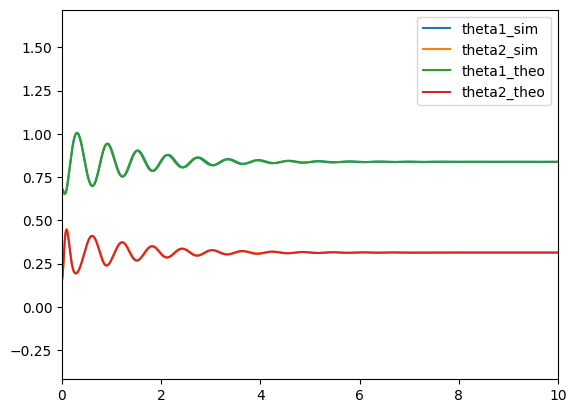

In [7]:
# Test One Group
exp_id = 11
plt.plot(t_sim_list[exp_id], theta1_sim_list[exp_id], label='theta1_sim')
plt.plot(t_sim_list[exp_id], theta2_sim_list[exp_id], label='theta2_sim')
plt.plot(t_all[exp_id], Xt_all[exp_id][:, 0], label='theta1_theo')
plt.plot(t_all[exp_id], Xt_all[exp_id][:, 1], label='theta2_theo')
plt.xlim(0, 10)
plt.legend()

In [8]:
# step_response_compare Function; point data for indexing

def step_response_compare(t_array_matlab, theta1_array_matlab, theta2_array_matlab, t_array_mujoco, theta1_array_mujoco, theta2_array_mujoco):
  """
  Compare the step response between theoretical (Matlab) and simulated (Mujoco) data.

  Parameters:
  - t_array_matlab (numpy.ndarray): Time array for Matlab data.
  - theta1_array_matlab (numpy.ndarray): Theta1 values from Matlab data.
  - theta2_array_matlab (numpy.ndarray): Theta2 values from Matlab data.
  - t_array_mujoco (numpy.ndarray): Time array for Mujoco data.
  - theta1_array_mujoco (numpy.ndarray): Theta1 values from Mujoco data.
  - theta2_array_mujoco (numpy.ndarray): Theta2 values from Mujoco data.

  Returns:
  - dict: A dictionary containing:
    - 'valid' (bool): Whether the data is within valid ranges.
    - 'RMSE_theta1' (float): Root Mean Square Error for Theta1.
    - 'RMSE_theta2' (float): Root Mean Square Error for Theta2.
    - 'MAE_theta1' (float): Mean Absolute Error for Theta1.
    - 'MAE_theta2' (float): Mean Absolute Error for Theta2.
    - 'MaxAE_theta1' (float): Maximum Absolute Error for Theta1.
    - 'MaxAE_theta2' (float): Maximum Absolute Error for Theta2.
  """
  # Calculate the MSE using interpolation over the interval [0-10s]
  t_interp = np.linspace(0, 10, 1000)
  theta1_sim_interp = np.interp(t_interp, t_array_mujoco, theta1_array_mujoco)
  theta2_sim_interp = np.interp(t_interp, t_array_mujoco, theta2_array_mujoco)
  theta1_theo_interp = np.interp(t_interp, t_array_matlab, theta1_array_matlab)
  theta2_theo_interp = np.interp(t_interp, t_array_matlab, theta2_array_matlab)

  # Check validity of data
  valid = True
  min_theta1 = min(np.min(theta1_sim_interp), np.min(theta1_theo_interp))
  max_theta1 = max(np.max(theta1_sim_interp), np.max(theta1_theo_interp))
  min_theta2 = min(np.min(theta2_sim_interp), np.min(theta2_theo_interp))
  max_theta2 = max(np.max(theta2_sim_interp), np.max(theta2_theo_interp))
  threshold = math.pi / 180  # 1 degree in radians
  if ((np.pi / 6 + threshold) >= min_theta1 or 
    max_theta1 >= (np.pi / 6 + 2 / 3 * np.pi - threshold) or 
    (0 + threshold) >= min_theta2 or 
    max_theta2 >= (0 + 2 / 3 * np.pi - threshold)):
    valid = False

  # Calculate errors
  RMSE_theta1 = np.sqrt(np.mean(np.square(theta1_sim_interp - theta1_theo_interp)))
  RMSE_theta2 = np.sqrt(np.mean(np.square(theta2_sim_interp - theta2_theo_interp)))
  MAE_theta1 = np.mean(np.abs(theta1_sim_interp - theta1_theo_interp))
  MAE_theta2 = np.mean(np.abs(theta2_sim_interp - theta2_theo_interp))
  MaxAE_theta1 = np.max(np.abs(theta1_sim_interp - theta1_theo_interp))
  MaxAE_theta2 = np.max(np.abs(theta2_sim_interp - theta2_theo_interp))

  return {
    'valid': valid,
    'RMSE_theta1': RMSE_theta1,
    'RMSE_theta2': RMSE_theta2,
    'MAE_theta1': MAE_theta1,
    'MAE_theta2': MAE_theta2,
    'MaxAE_theta1': MaxAE_theta1,
    'MaxAE_theta2': MaxAE_theta2
  }

# Test it
step_response_compare(
  t_all[exp_id], 
  Xt_all[exp_id][:, 0], 
  Xt_all[exp_id][:, 1], 
  t_sim_list[exp_id], 
  theta1_sim_list[exp_id], 
  theta2_sim_list[exp_id]
)

{'valid': True,
 'RMSE_theta1': np.float64(0.003458671287048678),
 'RMSE_theta2': np.float64(0.002655286663516892),
 'MAE_theta1': np.float64(0.002481919691065788),
 'MAE_theta2': np.float64(0.0015921140728586101),
 'MaxAE_theta1': np.float64(0.010401617544450237),
 'MaxAE_theta2': np.float64(0.016893482997888176)}

In [9]:
# Calculate the error for all data, save in csv file
swing_error_list = []
for i in tqdm(range(len(t_all))):
  result = step_response_compare(
    t_all[i], 
    Xt_all[i][:, 0], 
    Xt_all[i][:, 1], 
    t_sim_list[i], 
    theta1_sim_list[i], 
    theta2_sim_list[i]
  )
  swing_error_list.append(result)
# save as pd
swing_error_list = pd.DataFrame(swing_error_list)
swing_error_list.to_csv('data/swing_error_list.csv', index=False)

100%|██████████| 10000/10000 [00:02<00:00, 3693.95it/s]


In [10]:
# Load saved data and analysis
swing_error_list = pd.read_csv('data/swing_error_list.csv')
swing_error_valid = swing_error_list.query('valid==True')
swing_error_valid       # 5283 experiments data is valid

,valid,RMSE_theta1,RMSE_theta2,MAE_theta1,MAE_theta2,MaxAE_theta1,MaxAE_theta2
0,True,0.001077,0.003225,0.001074,0.003225,0.001485,0.003404
1,True,0.001765,0.001746,0.001486,0.001433,0.004342,0.010677
2,True,0.002886,0.002160,0.002290,0.001289,0.007253,0.018219
3,True,0.004004,0.003245,0.003116,0.002111,0.009723,0.027681
4,True,0.004921,0.004271,0.003814,0.002869,0.011557,0.036373
...,...,...,...,...,...,...,...
9995,True,0.001749,0.005167,0.001378,0.004321,0.007334,0.033349
9996,True,0.001529,0.004281,0.001347,0.003801,0.005704,0.024268
9997,True,0.001266,0.003756,0.001187,0.003553,0.003714,0.016722
9998,True,0.000895,0.003662,0.000882,0.003615,0.001653,0.010273


In [11]:
# Summary
max_RMSE_theta1 = swing_error_valid['RMSE_theta1'].max()
max_RMSE_theta2 = swing_error_valid['RMSE_theta2'].max()
max_MAE_theta1 = swing_error_valid['MAE_theta1'].max()
max_MAE_theta2 = swing_error_valid['MAE_theta2'].max()
max_MaxAE_theta1 = swing_error_valid['MaxAE_theta1'].max()
max_MaxAE_theta2 = swing_error_valid['MaxAE_theta2'].max()
# save to error_summary file
error_summary = {
  'max_RMSE_theta1': max_RMSE_theta1,
  'max_RMSE_theta2': max_RMSE_theta2,
  'max_MAE_theta1': max_MAE_theta1,
  'max_MAE_theta2': max_MAE_theta2,
  'max_MaxAE_theta1': max_MaxAE_theta1,
  'max_MaxAE_theta2': max_MaxAE_theta2
}
error_summary = pd.DataFrame(error_summary, index=[0])
error_summary.to_csv('data/swing_error_summary.csv', index=False)
error_summary


,max_RMSE_theta1,max_RMSE_theta2,max_MAE_theta1,max_MAE_theta2,max_MaxAE_theta1,max_MaxAE_theta2
0,0.011595,0.015693,0.005856,0.013174,0.06869,0.149943


In [12]:
# Show single experiment data

# Query the theta
Theta1_array = np.linspace(math.pi/6, math.pi*2/3, 11)[1:]
Theta2_array = np.linspace(0, math.pi/2, 11)[1:]


# Slide creation
slider_theta1_index_start = widgets.IntSlider(value=0, min=0, max=len(Theta1_array)-1, step=1, description='Theta1 Start Index')
slider_theta1_index_end = widgets.IntSlider(value=0, min=0, max=len(Theta1_array)-1, step=1, description='Theta1 End Index')
slider_theta2_index_start = widgets.IntSlider(value=0, min=0, max=len(Theta2_array)-1, step=1, description='Theta2 Start Index')
slider_theta2_index_end = widgets.IntSlider(value=0, min=0, max=len(Theta2_array)-1, step=1, description='Theta2 End Index')

config = {
    "font.family": 'Times New Roman',  # Set font type
    "axes.unicode_minus": False,  # Solve the problem of negative sign not displaying
    "font.size": 30,  # Set font size
    "axes.titlesize": 30,  # Set title font size
    "axes.labelsize": 25,  # Set axis label font size
    "xtick.labelsize": 20,  # Set x-axis tick font size
    "ytick.labelsize": 20,  # Set y-axis tick font size
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 16,
}

# Plot function
def update_plot(start_theta1_index, end_theta1_index, start_theta2_index, end_theta2_index):
    print(f"Start Point: {Theta1_array[start_theta1_index]}, {Theta2_array[start_theta2_index]}")
    print(f"End Point: {Theta1_array[end_theta1_index]}, {Theta2_array[end_theta2_index]}")

    exp_id = end_theta2_index + end_theta1_index * len(Theta2_array) + start_theta2_index * len(Theta2_array) * len(Theta1_array) + start_theta1_index * len(Theta2_array) * len(Theta1_array) * len(Theta2_array)
    valid = swing_error_list['valid'][exp_id]
    # interpolate the data
    t_interp = np.linspace(0, 10, 1000)
    theta1_sim_interp = np.interp(t_interp, t_sim_list[exp_id], theta1_sim_list[exp_id])
    theta2_sim_interp = np.interp(t_interp, t_sim_list[exp_id], theta2_sim_list[exp_id])
    theta1_theo_interp = np.interp(t_interp, t_all[exp_id], Xt_all[exp_id][:, 0])
    theta2_theo_interp = np.interp(t_interp, t_all[exp_id], Xt_all[exp_id][:, 1])    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200)
    
    # --- Top left: Time curve ---
    axs[0, 0].plot(t_interp, theta2_sim_interp, zorder=3)
    axs[0, 0].plot(t_interp, theta2_theo_interp, zorder=3)
    axs[0, 0].set_xlabel('Time/s')
    axs[0, 0].set_ylabel('Theta2/rad')
    axs[0, 0].set_title('Theta2 vs Time')
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)

    # Mark start and end points
    axs[0, 0].scatter(t_interp[0], theta2_sim_interp[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].scatter(t_interp[-1], theta2_sim_interp[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)

    edge = math.pi/6 * 0
    axs[0, 0].set_ylim([0, math.pi*2/3])
    axs[0, 0].set_xlim([-0.5, 10.5])

    axs[0, 0].set_xticks(np.arange(0, 10.5, 2))
    axs[0, 0].set_xticklabels([f'{round(i, 0)}' for i in np.arange(0, 10.5, 2)])
    axs[0, 0].set_yticks(np.arange(0, math.pi*2/3+edge, 0.25))
    axs[0, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi*2/3+edge, 0.25)])

    # --- Top right: Trajectory plot ---
    axs[0, 1].plot(theta1_sim_interp, theta2_sim_interp, alpha=0.6, zorder=3)  # Line
    axs[0, 1].scatter(theta1_sim_interp, theta2_sim_interp, s=3, label='Equivalent-Point', zorder=3)  # Scatter points
    axs[0, 1].plot(theta1_theo_interp, theta2_theo_interp, alpha=0.6, zorder=3)  # Line
    axs[0, 1].scatter(theta1_theo_interp, theta2_theo_interp, s=3, label='Theoretical-Point', zorder=3)  # Scatter points

    axs[0, 1].set_xlabel('Theta1/rad')
    axs[0, 1].set_ylabel('Theta2/rad')
    axs[0, 1].set_title('Theta Trajectory')
    axs[0, 1].set_xlim([math.pi/6-edge, math.pi/6+math.pi*2/3+edge])
    axs[0, 1].set_ylim([0-edge, math.pi*2/3+edge])

    axs[0, 1].grid(True, linestyle='--', alpha=0.5)

    axs[0, 1].set_xticks(np.arange(0.75,math.pi/6+math.pi*2/3+edge, 0.25))
    axs[0, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi/6+math.pi*2/3+edge, 0.25)])
    axs[0, 1].set_yticks(np.arange(0, math.pi*2/3+edge, 0.25))
    axs[0, 1].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi*2/3+edge, 0.25)])

    # Mark start and end points
    axs[0, 1].scatter(theta1_sim_interp[0], theta2_sim_interp[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].scatter(theta1_sim_interp[-1], theta2_sim_interp[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)

    # --- Bottom left: a_1cos(theta1) + a_2cos(theta2) ---
    a1 = 0.25
    a2 = 0.25

    flip = -1

    x_mujoco = (a1 * np.cos(theta1_sim_interp) + a2 * np.cos(theta2_sim_interp + theta1_sim_interp)) * flip
    y_mujoco = (a1 * np.sin(theta1_sim_interp) + a2 * np.sin(theta2_sim_interp + theta1_sim_interp)) * flip
    x_matlab = (a1 * np.cos(theta1_theo_interp) + a2 * np.cos(theta2_theo_interp + theta1_theo_interp)) * flip
    y_matlab = (a1 * np.sin(theta1_theo_interp) + a2 * np.sin(theta2_theo_interp + theta1_theo_interp)) * flip
    knee_x_mujoco = (a1 * np.cos(theta1_sim_interp)) * flip
    knee_y_mujoco = (a1 * np.sin(theta1_sim_interp)) * flip
    knee_x_matlab = (a1 * np.cos(theta1_theo_interp)) * flip
    knee_y_matlab = (a1 * np.sin(theta1_theo_interp)) * flip
    origin = np.zeros_like(x_mujoco)

    axs[1, 0].plot(x_mujoco, y_mujoco, label='Equivalent Trajectory')
    axs[1, 0].plot(x_matlab, y_matlab, label='Theoretical Trajectory')

    # interesting point
    index_interesting = [0, -1, len(t_interp)//30, len(t_interp)//100]

    for index in index_interesting:
        axs[1, 0].plot([origin[index], knee_x_mujoco[index], x_mujoco[index]], [origin[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion of Mujoco" if index==0 else "")

    axs[1, 0].scatter(x_mujoco[0], y_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 0].scatter(x_mujoco[-1], y_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 0].set_xlabel('x/m')
    axs[1, 0].set_ylabel('y/m')

    axs[1, 0].set_xlim([-0.5, 0.5])
    axs[1, 0].set_ylim(np.array([-0.55, 0.1]))

    axs[1, 0].set_xticks(np.arange(-0.5, 0.5, 0.1))
    axs[1, 0].set_xticklabels([f'{round(i, 2)}' for i in np.arange(-0.5, 0.5, 0.1)])
    axs[1, 0].set_yticks(np.arange(-0.55, 0.1, 0.1))
    axs[1, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(-0.55, 0.1, 0.1)])

    axs[1, 0].set_aspect('equal', adjustable='box')
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    axs[1, 0].set_title('Foot Trajectory')

    # --- Right Down：theta1 vs t ---
    axs[1, 1].plot(theta1_sim_interp, t_interp)
    axs[1, 1].plot(theta1_theo_interp, t_interp)

    axs[1, 1].set_xlabel('Theta1/rad')
    axs[1, 1].set_ylabel('Time/s')

    axs[1, 1].scatter(theta1_sim_interp[0], t_interp[0], s=100, color='purple', marker='*', alpha=0.9, zorder=5)
    axs[1, 1].scatter(theta1_sim_interp[-1], t_interp[-1], s=100, color='red', marker='*', alpha=0.9, zorder=5)

    axs[1, 1].set_title('Theta1 vs Time')
    axs[1, 1].set_xlim([math.pi/6, math.pi/6 + math.pi*2/3])
    axs[1, 1].grid(True, linestyle='--', alpha=0.5)

    axs[1, 1].set_xticks(np.arange(0.75,math.pi/6+math.pi*2/3, 0.25))
    axs[1, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi/6+math.pi*2/3, 0.25)])
    axs[1, 1].set_yticks(np.arange(0, 11, 2))
    axs[1, 1].set_yticklabels([f'{round(i, 1)}' for i in np.arange(0, 11, 2)])

    legend = fig.legend(
        loc='upper left',
        bbox_to_anchor=(0.2, 0.76),
        fontsize=legendSet['fontsize'],
        frameon=True,
    )
    legend.set_zorder(0)
    legend.get_frame().set_alpha(0.6)

    if not valid:
        fig.suptitle("Simulated Verification: (a) Swing Phase - Invalid Data!", fontsize=30, color='red')
    else:
        fig.suptitle("Simulated Verification: (a) Swing Phase - Valid Data", fontsize=30)

    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.show()

    return fig

interactive_plot = widgets.interactive(update_plot, 
    start_theta1_index=slider_theta1_index_start, 
    end_theta1_index=slider_theta1_index_end, 
    start_theta2_index=slider_theta2_index_start, 
    end_theta2_index=slider_theta2_index_end
)

display(interactive_plot)

interactive(children=(IntSlider(value=0, description='Theta1 Start Index', max=9), IntSlider(value=0, descript…

Start Point: 0.9948376736367678, 0.3141592653589793
End Point: 1.6231562043547263, 1.2566370614359172


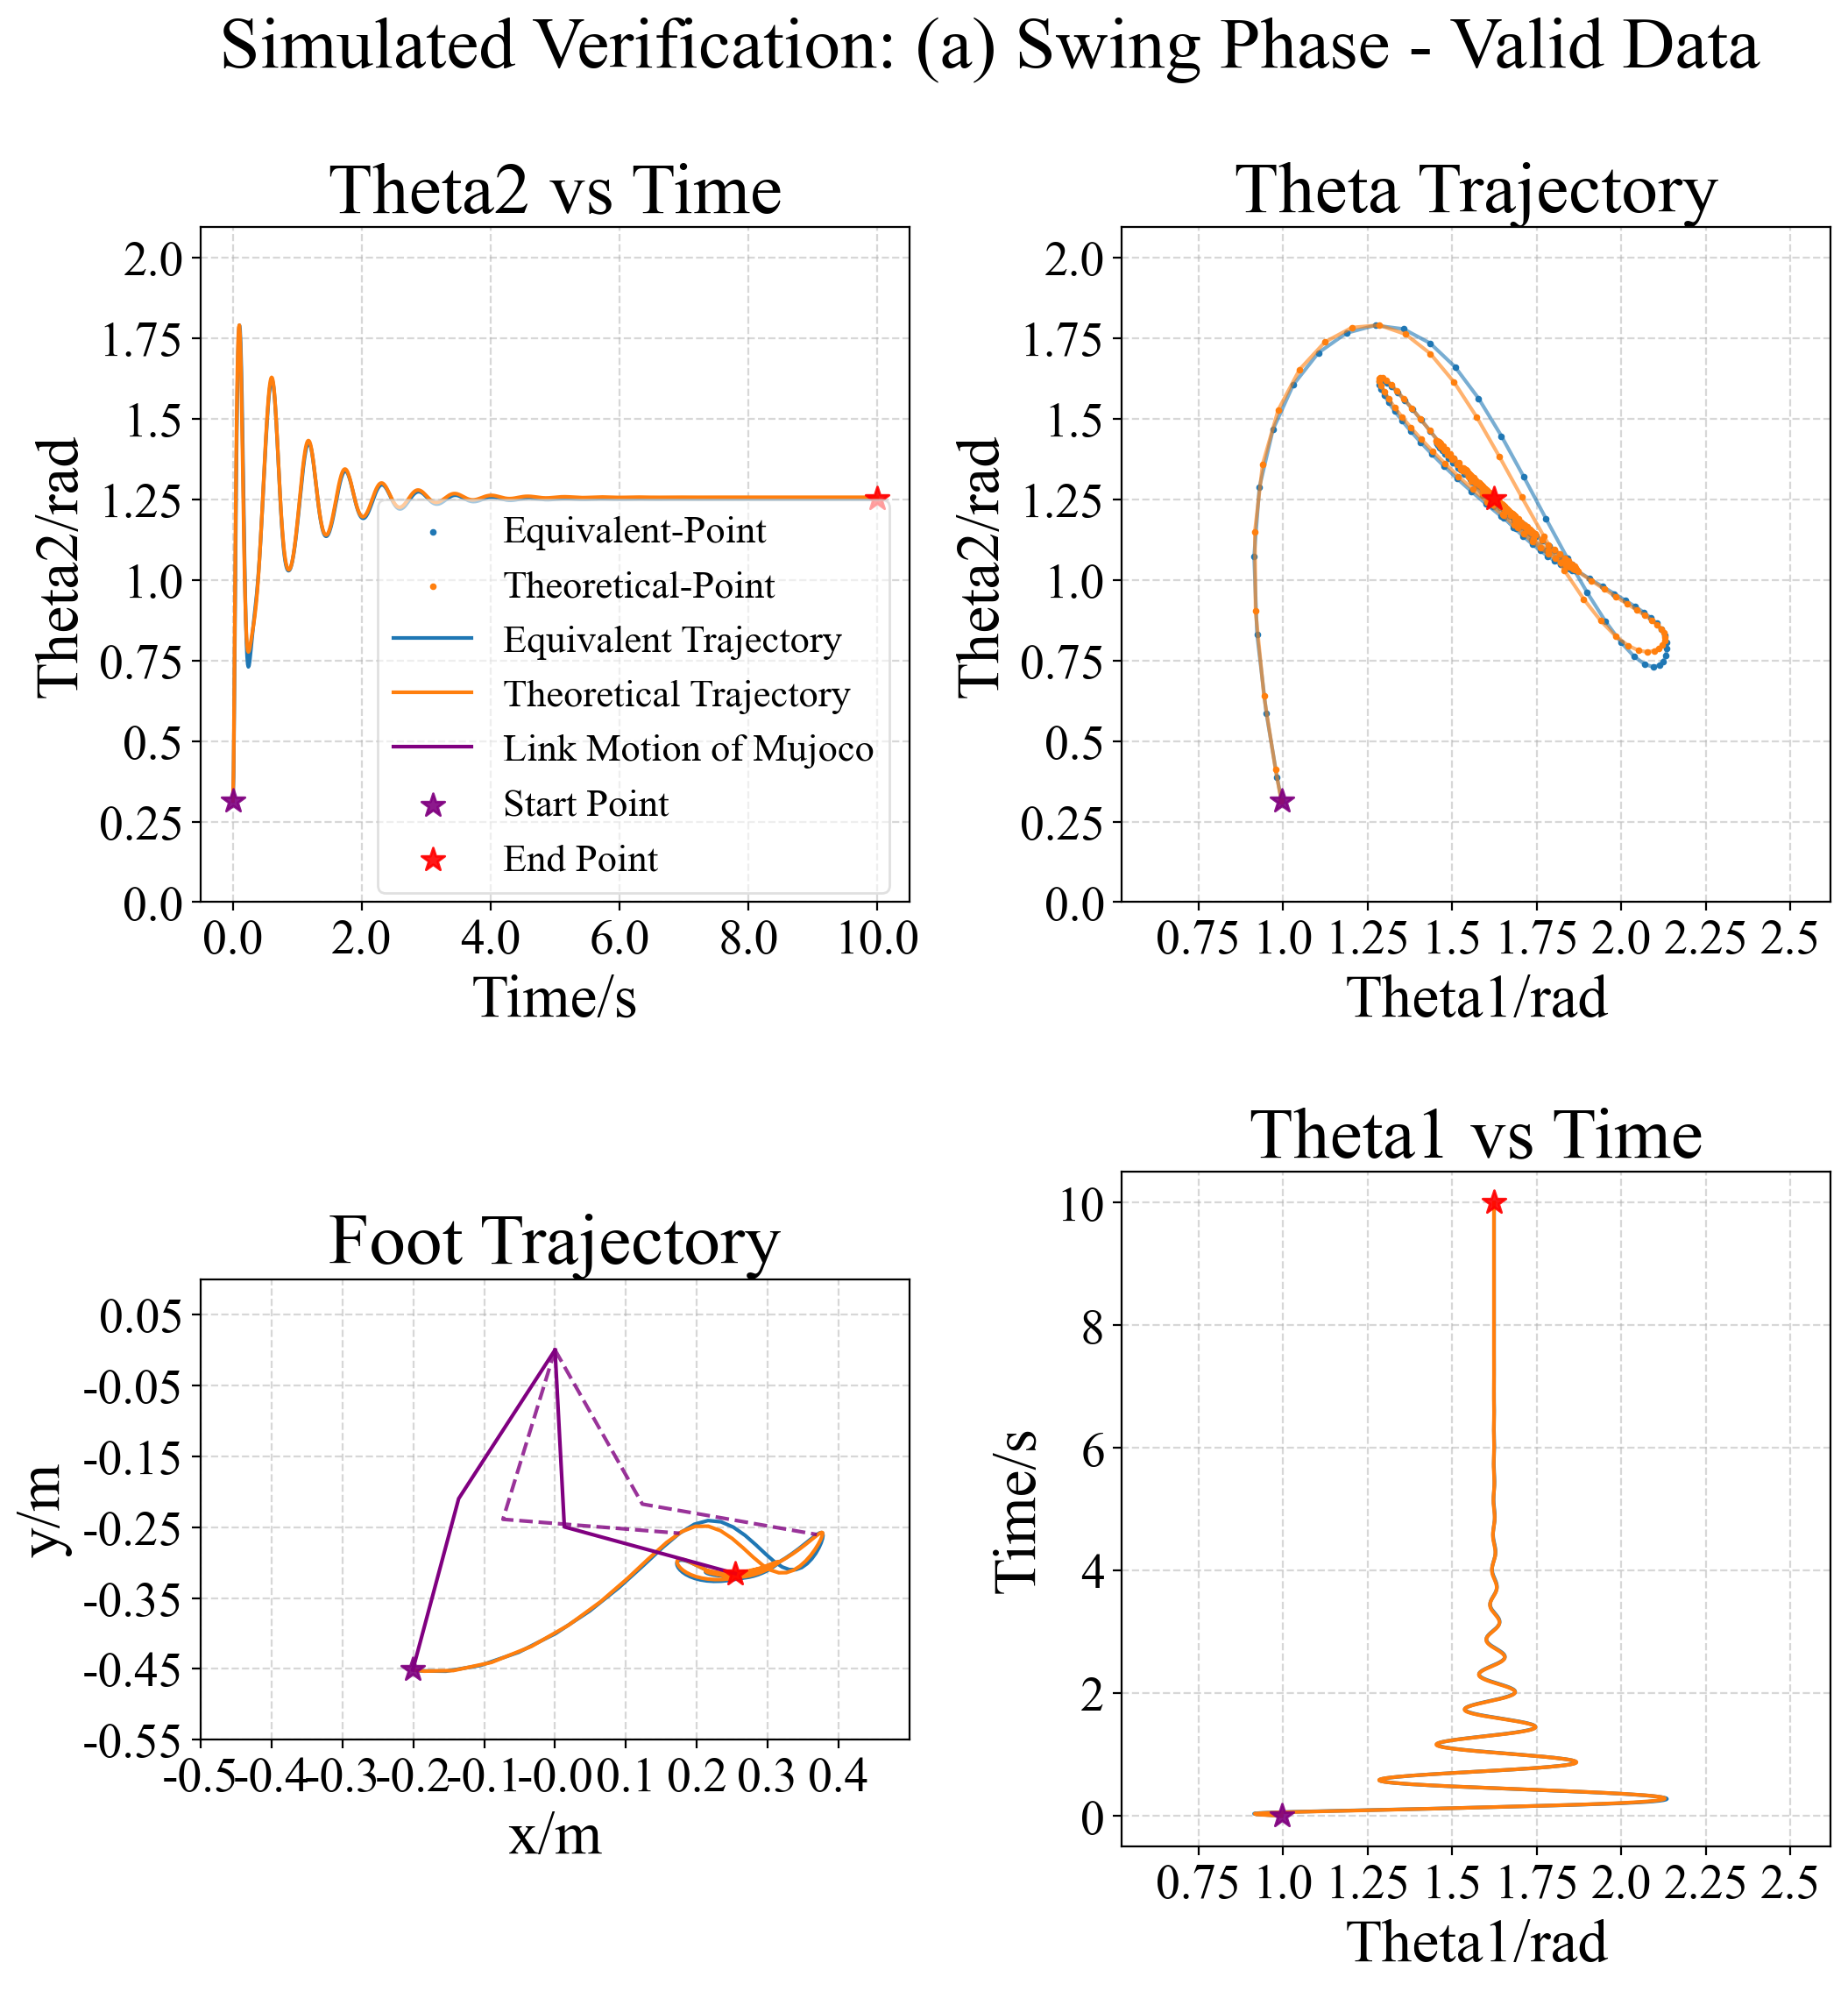

In [13]:
# For paper writing
fig_tosave = update_plot(
    start_theta1_index=2, 
    start_theta2_index=1, 
    end_theta1_index=6, 
    end_theta2_index=7
)
fig_tosave.savefig('figure/swing_phase2167.png', dpi=200, bbox_inches='tight')